In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sys
sys.path.append("../")
from src.visualize import plot_hist_comparison, plot_kde_comparison, plot_returns_vol_scatter
from src.volatility import calc_abs_corr




In [2]:
returns_lehman = pd.read_csv("../data/processed/log_returns_lehman.csv", index_col=0, parse_dates=True)
returns_covid = pd.read_csv("../data/processed/log_returns_covid.csv", index_col=0, parse_dates=True)
returns_tramp_tariff = pd.read_csv("../data/processed/log_returns_tramp_tariff.csv", index_col=0, parse_dates=True)
rolling_vol_lehman = pd.read_csv("../data/features/rolling_volatility_lehman.csv", index_col=0, parse_dates=True)
rolling_vol_covid = pd.read_csv("../data/features/rolling_volatility_covid.csv", index_col=0, parse_dates=True)
rolling_vol_tramp_tariff = pd.read_csv("../data/features/rolling_volatility_tramp_tariff.csv", index_col=0, parse_dates=True)

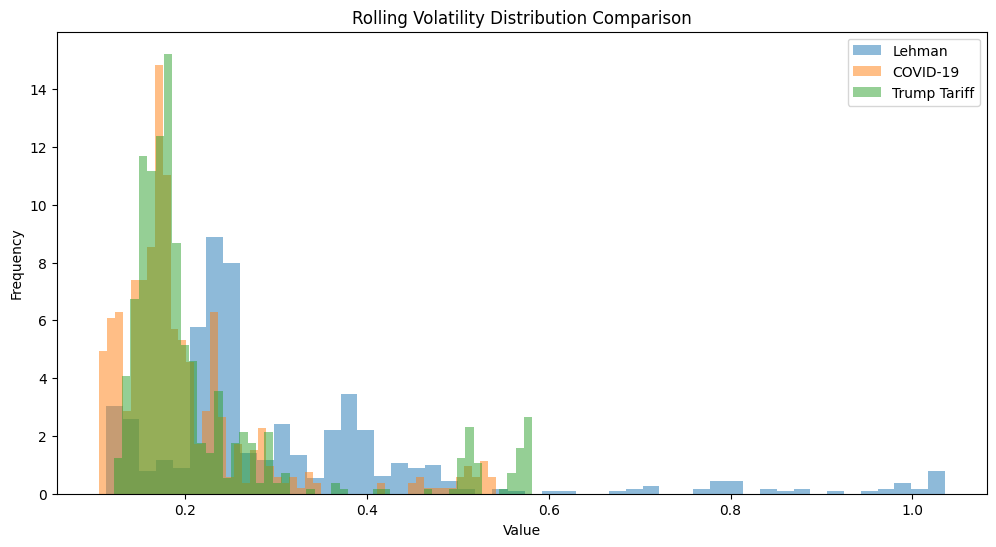

In [3]:
data = {
    "Lehman": rolling_vol_lehman["^N225"],
    "COVID-19": rolling_vol_covid["^N225"],
    "Trump Tariff": rolling_vol_tramp_tariff["^N225"]
}
plot_hist_comparison(data, title="Rolling Volatility Distribution Comparison")

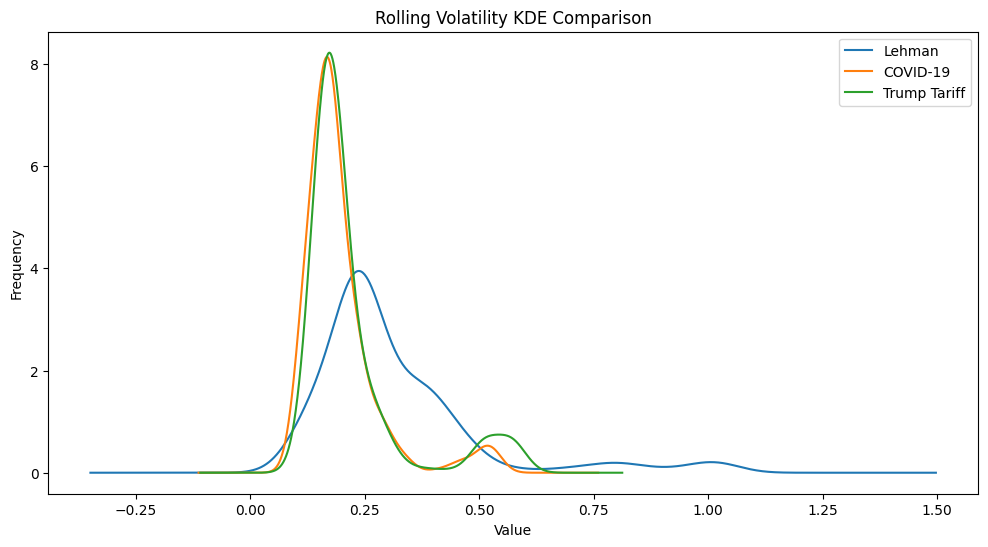

In [4]:
plot_kde_comparison(data, title="Rolling Volatility KDE Comparison")

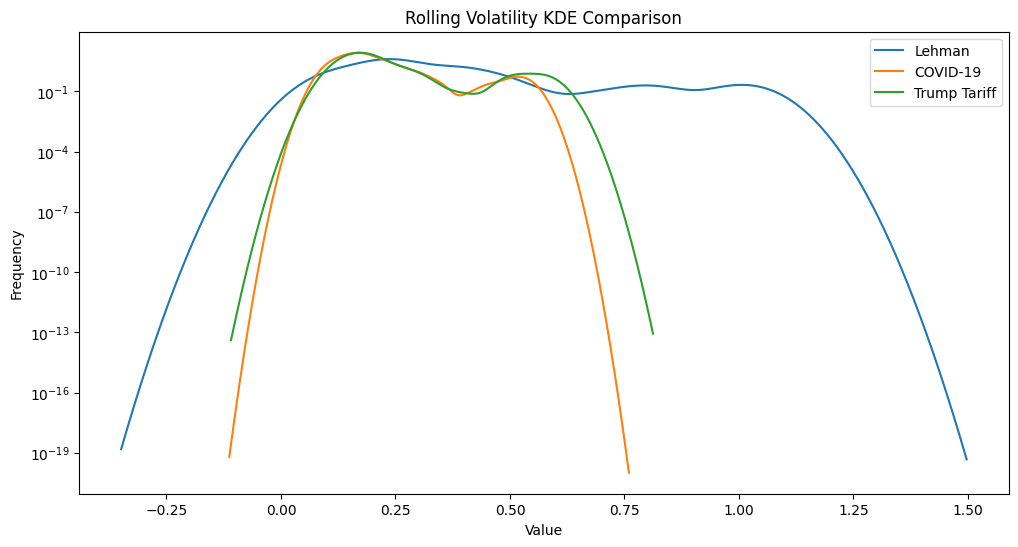

In [5]:
plot_kde_comparison(data, title="Rolling Volatility KDE Comparison", log_scale=True)

In [6]:
#returnsの歪度計算
print(returns_lehman.skew())
print(returns_covid.skew())
print(returns_tramp_tariff.skew())


^AXJO    -0.345355
^BVSP     0.187781
^DJI     -0.095635
^FTSE     0.140000
^GDAXI    0.384843
^GSPC    -0.241313
^HSI      0.045653
^IXIC    -0.372484
^N225    -0.500293
dtype: float64
^AXJO    -1.393576
^BVSP    -1.559677
^DJI     -1.218997
^FTSE    -1.139090
^GDAXI   -1.006498
^GSPC    -1.236354
^HSI     -0.178644
^IXIC    -0.989372
^N225     0.114166
dtype: float64
^AXJO    -1.001632
^BVSP     0.137675
^DJI      0.131073
^FTSE    -2.951889
^GDAXI   -1.338335
^GSPC     0.334147
^HSI     -1.171333
^IXIC     0.444952
^N225    -1.080941
dtype: float64


In [7]:
#returnsの尖度計算
print(returns_lehman.kurtosis())
print(returns_covid.kurtosis())
print(returns_tramp_tariff.kurtosis())

^AXJO     4.299599
^BVSP     4.701588
^DJI      5.394862
^FTSE     5.959570
^GDAXI    6.674917
^GSPC     5.218661
^HSI      5.691847
^IXIC     3.525472
^N225     6.728358
dtype: float64
^AXJO     13.232308
^BVSP     16.262221
^DJI      19.073121
^FTSE     14.561674
^GDAXI    15.458801
^GSPC     17.213011
^HSI       1.524659
^IXIC     11.707134
^N225      4.392676
dtype: float64
^AXJO      9.533991
^BVSP      2.402986
^DJI      12.624129
^FTSE     34.266001
^GDAXI    12.805872
^GSPC     13.420268
^HSI      10.996530
^IXIC      9.248242
^N225     16.980025
dtype: float64


In [8]:
#上位5%（極端リスク）
print(rolling_vol_lehman.quantile(0.95))
print(rolling_vol_covid.quantile(0.95))
print(rolling_vol_tramp_tariff.quantile(0.95))

^AXJO     0.523767
^BVSP     0.913275
^DJI      0.658920
^FTSE     0.668305
^GDAXI    0.677761
^GSPC     0.721153
^HSI      0.772102
^IXIC     0.678872
^N225     0.784360
Name: 0.95, dtype: float64
^AXJO     0.502679
^BVSP     0.820926
^DJI      0.627874
^FTSE     0.464548
^GDAXI    0.507007
^GSPC     0.597686
^HSI      0.321652
^IXIC     0.589168
^N225     0.405037
Name: 0.95, dtype: float64
^AXJO     0.174311
^BVSP     0.225612
^DJI      0.265407
^FTSE     0.195794
^GDAXI    0.234810
^GSPC     0.289897
^HSI      0.471879
^IXIC     0.345249
^N225     0.518260
Name: 0.95, dtype: float64


In [9]:
#最大値
print(rolling_vol_lehman.max())
print(rolling_vol_covid.max())
print(rolling_vol_tramp_tariff.max())

^AXJO     0.633266
^BVSP     1.143819
^DJI      0.790134
^FTSE     0.810756
^GDAXI    0.830300
^GSPC     0.845079
^HSI      1.040898
^IXIC     0.776425
^N225     1.035499
dtype: float64
^AXJO     0.708464
^BVSP     1.129090
^DJI      0.954896
^FTSE     0.636490
^GDAXI    0.696499
^GSPC     0.891518
^HSI      0.361205
^IXIC     0.858716
^N225     0.541522
dtype: float64
^AXJO     0.285187
^BVSP     0.279164
^DJI      0.368124
^FTSE     0.339705
^GDAXI    0.392821
^GSPC     0.422956
^HSI      0.520299
^IXIC     0.517211
^N225     0.581888
dtype: float64


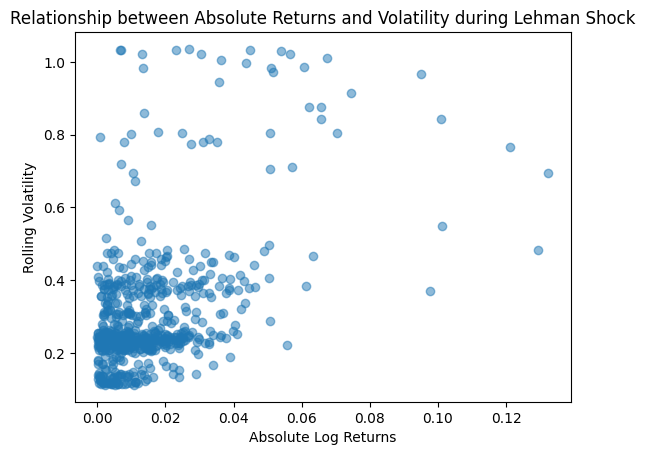

In [12]:
plot_returns_vol_scatter(returns_lehman["^N225"], rolling_vol_lehman["^N225"], title="Relationship between Absolute Returns and Volatility during Lehman Shock")

In [15]:
print(calc_abs_corr(returns_lehman["^N225"], rolling_vol_lehman["^N225"]))

0.49576829152898644
